In [1]:
%load_ext autoreload
%autoreload 2

In [77]:
import crafter.functional_env as func_env
from crafter.testing_helpers import player_utils, world_utils
from PIL import Image
from crafter.state_export import Position, PlayerState, WorldState
from typing import Callable
from crafter.constants import ActionT as CrafterAction
from crafter.constants import MaterialT as CrafterMaterial
from typing import Iterator, Optional
from crafter.engine import World

In [ ]:
state = func_env.initial_state(seed=42)
observation = func_env.observation(state, (1024, 1024))
image = Image.fromarray(observation)
image.save("observation.png")

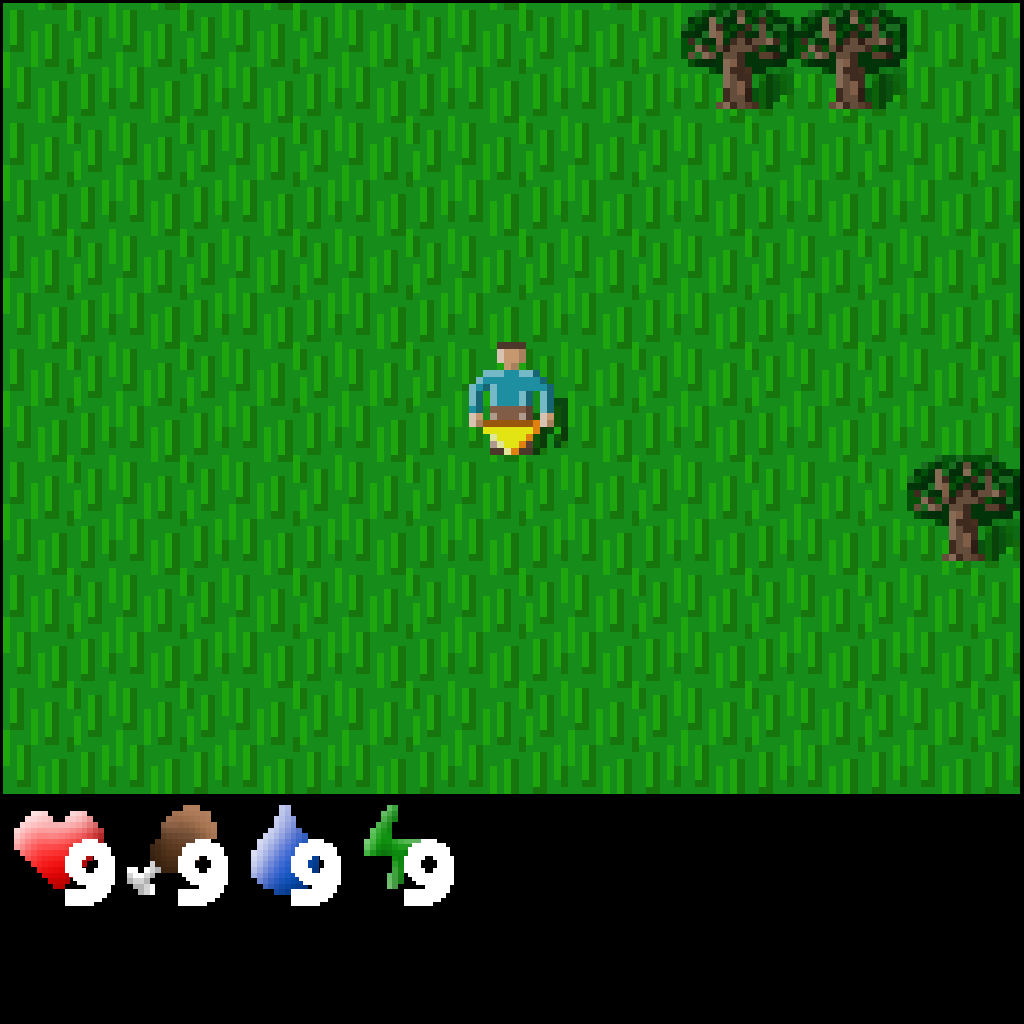

In [4]:
image

In [ ]:
class PathfindOption:
    def __init__(
        self,
        source_pos_fn: Callable[[], Position],
        target_pos_fn: Callable[[], Position],
        max_steps: Optional[int] = None,
    ):
        self.source_pos_fn = source_pos_fn
        self.target_pos_fn = target_pos_fn
        self.max_steps = max_steps

    def __iter__(self) -> Iterator[CrafterAction]:
        steps = 0
        print("iter")
        while True:
            source = self.source_pos_fn()
            target = self.target_pos_fn()

            dx = target.x - source.x
            dy = target.y - source.y

            print(dx, dy)

            if abs(dx) + abs(dy) <= 1:
                return
            if abs(dx) >= abs(dy):
                yield "move_right" if dx > 0 else "move_left"
            else:
                yield "move_down" if dy > 0 else "move_up"

            steps += 1
            if self.max_steps is not None and steps >= self.max_steps:
                return

In [52]:
class TerminationCondition(Exception):
    pass


class PlayerPathfindOption:
    def __init__(
        self,
        target_pos_fn: Callable[[WorldState], Position],
        max_steps: Optional[int] = None,
    ):
        self.target_pos_fn = target_pos_fn
        self.max_steps = max_steps
        self.steps = 0

    def action(self, state: WorldState) -> CrafterAction:
        target_pos = self.target_pos_fn(state)
        player_pos = state.player.position

        dx = target_pos.x - player_pos.x
        dy = target_pos.y - player_pos.y

        if abs(dx) + abs(dy) <= 1:
            raise TerminationCondition()

        if self.max_steps is not None and self.steps >= self.max_steps:
            raise TerminationCondition()

        if abs(dx) >= abs(dy):
            self.steps += 1
            return "move_right" if dx > 0 else "move_left"
        else:
            self.steps += 1
            return "move_down" if dy > 0 else "move_up"

In [71]:
import numpy as np


class PlayerInteractAdjacentOption:
    def __init__(self, target_pos_fn: Callable[[WorldState], Position]):
        self.target_pos_fn = target_pos_fn
        self.attempted_face_target = False

    @staticmethod
    def _remap_direction(direction: np.ndarray) -> CrafterAction:
        x, y = direction
        match x, y:
            case 1, 0:
                return "move_right"
            case -1, 0:
                return "move_left"
            case 0, 1:
                return "move_down"
            case 0, -1:
                return "move_up"
            case _:
                raise ValueError(f"Invalid direction: {direction}")

    def action(self, state: WorldState) -> CrafterAction:
        if not self.attempted_face_target:
            target_pos = self.target_pos_fn(state)
            direction = state.player.toward(target_pos)
            self.attempted_face_target = True
            return self._remap_direction(direction)
        else:
            self.attempted_face_target = False
            return "do"

In [54]:
import numpy as np


class InteractAdjacentOption:
    def __init__(
        self,
        target_pos_fn: Callable[[], Position],
        player_fn: Callable[[], PlayerState],
    ):
        self.target_pos_fn = target_pos_fn
        self.player_fn = player_fn

    def _remap_direction(self, direction: np.ndarray) -> CrafterAction:
        x, y = direction
        match x, y:
            case 1, 0:
                return "move_right"
            case -1, 0:
                return "move_left"
            case 0, 1:
                return "move_down"
            case 0, -1:
                return "move_up"
            case _:
                raise ValueError(f"Invalid direction: {direction}")

    def __iter__(self) -> Iterator[CrafterAction]:
        # First we make the player face the target
        target_pos = self.target_pos_fn()
        player_pos = self.player_fn()
        direction = player_pos.toward(target_pos)
        yield self._remap_direction(direction)

        # Then we interact with the target
        yield "do"

In [55]:
from crafter.state_export import WorldState
from typing import cast


def find_materials_of_type(
    state: WorldState, material_type: str
) -> list[tuple[CrafterMaterial, Position]]:
    materials: list[tuple[CrafterMaterial, Position]] = []
    for x in range(len(state.materials)):
        for y in range(len(state.materials[x])):
            if state.materials[x][y] == material_type:
                materials.append(
                    (cast(CrafterMaterial, state.materials[x][y]), Position(x=x, y=y))
                )
    return materials

In [56]:
def find_closest_material_of_type(
    state: WorldState, material_type: str
) -> tuple[CrafterMaterial, Position]:
    materials = find_materials_of_type(state, material_type)
    return min(materials, key=lambda x: x[1].distance(state.player.position))

In [57]:
find_closest_material_of_type(state, "tree")

('tree', Position(x=34, y=29))

In [58]:
from copy import deepcopy
from distant_sunburn.our_method.action_remapping import remap_slug_actions_to_int_index
from pathlib import Path

frame_dir = Path("frames")
frame_dir.mkdir(exist_ok=True)


def run_hierarchical_policy(state: WorldState):
    target_mat, target_pos = find_closest_material_of_type(state, "tree")
    policy = PathfindOption(
        lambda: state.player.position, lambda: target_pos, max_steps=50
    )
    steps = 0
    for action in policy:
        steps += 1
        print(action)
        state, _ = func_env.transition(
            deepcopy(state), remap_slug_actions_to_int_index(action)
        )
        observation = func_env.observation(state, (1024, 1024))
        image = Image.fromarray(observation)
        image.save(frame_dir / f"{steps:04d}.png")

    policy = InteractAdjacentOption(
        lambda: target_pos,
        lambda: state.player,
    )
    for action in policy:
        steps += 1
        print(action)
        state, _ = func_env.transition(
            deepcopy(state), remap_slug_actions_to_int_index(action)
        )
        observation = func_env.observation(state, (1024, 1024))
        image = Image.fromarray(observation)
        image.save(frame_dir / f"{steps:04d}.png")


run_hierarchical_policy(state)

iter
2 -3
move_up
2 -2
move_right
1 -2
move_up
1 -1
move_right
0 -1
move_up
do


In [76]:
class CombatFixedEntityPolicy:
    def __init__(self, entity_id: int):
        self.entity_id = entity_id

    @staticmethod
    def _remap_direction(direction: np.ndarray) -> CrafterAction:
        x, y = direction
        match x, y:
            case 1, 0:
                return "move_right"
            case -1, 0:
                return "move_left"
            case 0, 1:
                return "move_down"
            case 0, -1:
                return "move_up"
            case _:
                raise ValueError(f"Invalid direction: {direction}")

    def action(self, state: WorldState) -> CrafterAction:
        # First we find the entity in the game state
        entity = next((e for e in state.objects if e.entity_id == self.entity_id), None)
        if entity is None:
            # We've defeated the entity or it doesn't exist
            raise TerminationCondition()

        _, target_entity = state.get_target_tile()
        if target_entity is None:
            # We have to move towards the entity
            chase_vector = state.player.toward(entity.position)
            return self._remap_direction(chase_vector)
        else:
            # We are already facing the entity
            return "do"

In [97]:
frame_dir = Path("frames")
frame_dir.mkdir(exist_ok=True)


def run_tree_chopper_policy(state: WorldState) -> tuple[WorldState, World]:
    trees_chopped = 0
    policy = PlayerPathfindOption(
        lambda state: find_closest_material_of_type(state, "tree")[1],
    )
    interact_policy = PlayerInteractAdjacentOption(
        lambda state: find_closest_material_of_type(state, "tree")[1],
    )
    while True:
        try:
            action = policy.action(state)
            print(action)
        except TerminationCondition:
            action = interact_policy.action(state)
            print(action)
            if action == "do":
                trees_chopped += 1
        state, _ = func_env.transition(
            deepcopy(state), remap_slug_actions_to_int_index(action)
        )
        observation = func_env.observation(state, (1024, 1024))
        image = Image.fromarray(observation)
        image.save(frame_dir / f"{state.step_count:04d}.png")

        if trees_chopped >= 4:
            break

    # Now we craft a wooden sword
    # First we put down a crafting table
    state, _ = func_env.transition(
        deepcopy(state), remap_slug_actions_to_int_index("place_table")
    )
    observation = func_env.observation(state, (1024, 1024))
    image = Image.fromarray(observation)
    image.save(frame_dir / f"{state.step_count:04d}.png")

    # Now we craft a wooden sword
    state, world = func_env.transition(
        deepcopy(state), remap_slug_actions_to_int_index("make_wood_sword")
    )
    observation = func_env.observation(state, (1024, 1024))
    image = Image.fromarray(observation)
    image.save(frame_dir / f"{state.step_count:04d}.png")

    return state, world


post_tree_chopper_state, post_tree_chopper_world = run_tree_chopper_policy(state)

move_up
move_right
move_up
move_right
move_up
do
move_up
move_up
do
move_right
do
move_left
move_left
move_up
move_left
move_up
do


In [ ]:
from crafter.objects import Player, Zombie
from crafter.state_export import export_world_state


def run_zombie_defeat_policy(
    state: WorldState, world: World
) -> tuple[WorldState, World]:
    # First we add a zombie to the world
    player = next(_ for _ in world.objects if isinstance(_, Player))
    assert player is not None

    zombie_pos = (state.player.position.x + 3, state.player.position.y + 3)

    zombie = Zombie(world, zombie_pos, player)

    world.add(zombie)

    state = export_world_state(world, state.view, state.step_count)
    observation = func_env.observation(state, (1024, 1024))
    image = Image.fromarray(observation)
    image.save(frame_dir / f"{state.step_count:04d}.png")

    combat_zombie_policy = CombatFixedEntityPolicy(entity_id=zombie.entity_id)

    for _ in range(10):
        try:
            action = combat_zombie_policy.action(state)
        except TerminationCondition:
            break
        state, world = func_env.transition(
            deepcopy(state), remap_slug_actions_to_int_index(action)
        )
        observation = func_env.observation(state, (1024, 1024))
        image = Image.fromarray(observation)
        image.save(frame_dir / f"{state.step_count:04d}.png")

    return state, world

In [99]:
run_zombie_defeat_policy(post_tree_chopper_state, post_tree_chopper_world)

(WorldState(size=(64, 64), chunk_size=(12, 12), view=(9, 9), daylight=0.9576476345196044, objects=[PlayerState(entity_id=0, position=Position(x=31, y=31), health=8, name='player', removed=False, facing=Position(x=1, y=0), action='do', sleeping=False, achievements=Achievements(collect_coal=0, collect_diamond=0, collect_drink=0, collect_iron=0, collect_sapling=0, collect_stone=0, collect_wood=4, defeat_skeleton=0, defeat_zombie=1, eat_cow=0, eat_plant=0, make_iron_pickaxe=0, make_iron_sword=0, make_stone_pickaxe=0, make_stone_sword=0, make_wood_pickaxe=0, make_wood_sword=1, place_furnace=0, place_plant=0, place_stone=0, place_table=1, wake_up=0), inventory=Inventory(health=8, food=8, drink=8, energy=9, sapling=0, wood=1, stone=0, coal=0, iron=0, diamond=0, wood_pickaxe=0, stone_pickaxe=0, iron_pickaxe=0, wood_sword=1, stone_sword=0, iron_sword=0), thirst=5.0, hunger=0.0, fatigue=26.0, recover=0.0, last_health=8), ZombieState(entity_id=2, position=Position(x=2, y=25), health=5, name='zomb